In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import percentileofscore
from scipy.stats import ttest_1samp

## Loading the datasets

In [2]:
# Fina:
mld_fina = xr.open_dataset(r'C:\Users\tilde\Documents\GitHub\Cyclone-Analysis\MLD\Fina\cmems_mod_glo_phy-all_my_0.25deg_P1D-m_1777721705793.nc')

# Alfred:
mld_alfred = xr.open_dataset(r'C:\Users\tilde\Documents\GitHub\Cyclone-Analysis\MLD\Alfred\cmems_mod_glo_phy_anfc_0.083deg_P1D-m_1777721605785.nc')

# Baseline (three separate files, one per year):
mld_baseline_first  = xr.open_dataset(r'C:\Users\tilde\Documents\GitHub\Cyclone-Analysis\MLD\Baseline\cmems_mod_glo_phy-all_my_0.25deg_P1D-m_1777721763579.nc')
mld_baseline_second = xr.open_dataset(r'C:\Users\tilde\Documents\GitHub\Cyclone-Analysis\MLD\Baseline\cmems_mod_glo_phy-all_my_0.25deg_P1D-m_1777721781630.nc')
mld_baseline_third  = xr.open_dataset(r'C:\Users\tilde\Documents\GitHub\Cyclone-Analysis\MLD\Baseline\cmems_mod_glo_phy-all_my_0.25deg_P1D-m_1777721798329.nc')

In [3]:
# Checking variable names
mld_fina

<xarray.Dataset> Size: 863kB
Dimensions:      (time: 62, latitude: 57, longitude: 61)
Coordinates:
  * time         (time) datetime64[ns] 496B 2011-12-01 2011-12-02 ... 2012-01-31
  * latitude     (latitude) float32 228B -27.0 -26.75 -26.5 ... -13.25 -13.0
  * longitude    (longitude) float32 244B 150.0 150.2 150.5 ... 164.8 165.0
Data variables:
    mlotst_cglo  (time, latitude, longitude) float32 862kB ...
Attributes: (12/13)
    Conventions:       CF-1.11
    title:             Daily mean fields for product GLOBAL_MULTIYEAR_PHY_ENS...
    institution:       Mercator Ocean
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            Copernicus Marine Service
    history:           Creation 2023-October-31 12:35:28 GMT+0200
    ...                ...
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_ENS_001_031
    subset:datasetId:  cmems_mod_glo_phy-all_my_0.25deg_P1D-m_202311
    subset:date:       2026-05-02T11:35:05.794Z

In [4]:
# Extracting the MLD variable from each dataset
mld_fina = mld_fina['mlotst_cglo']
mld_alfred = mld_alfred['mlotst']
mld_baseline_first  = mld_baseline_first['mlotst_cglo']
mld_baseline_second = mld_baseline_second['mlotst_cglo']
mld_baseline_third  = mld_baseline_third['mlotst_cglo']

## Excluding cyclones from baseline

In [5]:
exclude_periods = [
    ('2020-02-04', '2020-02-14'),
    ('2020-03-14', '2020-03-15'),
    ('2021-01-16', '2021-01-19'),
    ('2021-01-24', '2021-02-01'),
    ('2021-02-27', '2021-03-05'),
    ('2021-12-09', '2021-12-15'),
    ('2022-02-07', '2022-02-12')
]

def exclude_periods_from_da(da, exclude_periods):
    """Remove specific date ranges from a DataArray."""
    keep_mask = xr.ones_like(da.time, dtype=bool)
    for start, end in exclude_periods:
        keep_mask = keep_mask & ~(
            (da.time >= np.datetime64(start)) &
            (da.time <= np.datetime64(end))
        )
    return da.sel(time=keep_mask)

mld_baseline_first_clean  = exclude_periods_from_da(mld_baseline_first,  exclude_periods)
mld_baseline_second_clean = exclude_periods_from_da(mld_baseline_second, exclude_periods)
mld_baseline_third_clean  = exclude_periods_from_da(mld_baseline_third,  exclude_periods)

## Spatial means and anomalies

In [6]:
dims = ("latitude", "longitude")

mld_ts_fina   = mld_fina.mean(dim=dims)
mld_ts_alfred = mld_alfred.mean(dim=dims)

mld_ts_baseline_first  = mld_baseline_first_clean.mean(dim=dims)
mld_ts_baseline_second = mld_baseline_second_clean.mean(dim=dims)
mld_ts_baseline_third  = mld_baseline_third_clean.mean(dim=dims)

# Combine all three baseline years into one time series for the climatology plots
mld_ts_baseline = xr.concat(
    [mld_ts_baseline_first, mld_ts_baseline_second, mld_ts_baseline_third],
    dim="time"
)

# Overall baseline mean (scalar)
mld_baseline_mean = mld_ts_baseline.mean(dim='time')

# Anomalies
baseline_on_alfred = mld_baseline_mean.interp_like(mld_ts_alfred)
mld_alfred_anomaly = mld_ts_alfred - baseline_on_alfred

baseline_on_fina = mld_baseline_mean.interp_like(mld_ts_fina)
mld_fina_anomaly = mld_ts_fina - baseline_on_fina

print("Max MLD anomaly for Alfred:", mld_alfred_anomaly.max().values, "m")
print("Max MLD anomaly for Fina:",   mld_fina_anomaly.max().values,   "m")

Max MLD anomaly for Alfred: 20.132092 m
Max MLD anomaly for Fina: 4.6565933 m


## Plots

In [7]:
# Converting to "days since first data point" so I can plot both in one graph
mld_ts_fina_rel = mld_ts_fina.copy()
mld_ts_alfred_rel = mld_ts_alfred.copy()

mld_ts_fina_rel['time'] = (mld_ts_fina.time - mld_ts_fina.time[0]) / np.timedelta64(1, 'D')
mld_ts_alfred_rel['time'] = (mld_ts_alfred.time - mld_ts_alfred.time[0]) / np.timedelta64(1, 'D')

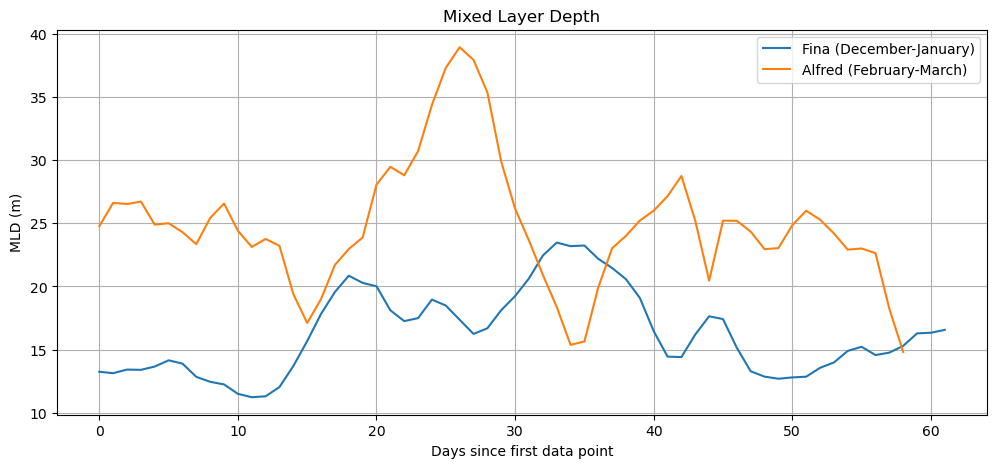

In [8]:
# Plotting time series for Alfred and Fina
fig, ax = plt.subplots(figsize=(12, 5))

mld_ts_fina_rel.plot(ax=ax, label='Fina (December-January)')
mld_ts_alfred_rel.plot(ax=ax, label='Alfred (February-March)')

ax.legend()
ax.set_title("Mixed Layer Depth")
ax.set_ylabel("MLD (m)")
ax.set_xlabel("Days since first data point")

ax.grid(True)

In [9]:
# Adding day-of-year coordinates for baseline but only for Dec-Mar
mld_ts_season = mld_ts_baseline.where(
    mld_ts_baseline['time'].dt.month.isin([11, 12, 1, 2, 3]),
    drop=True
)

mld_ts_season = mld_ts_season.assign_coords(
    dayofyear=mld_ts_season['time'].dt.dayofyear
)

# Grouping it by day of year and taking the mean to get climatology
mld_clim = mld_ts_season.groupby('dayofyear').mean(dim='time')

# Setting November as first day of the season (day 0) and March as last day (day 151)
doy = mld_clim['dayofyear']

season_index = xr.where(
    doy >= 305,
    doy - 305,
    doy + (365 - 305 + 1)
)

mld_clim = mld_clim.assign_coords(season_index=season_index)
mld_clim = mld_clim.sortby('season_index')

[Text(0, 0, 'Nov'),
 Text(30, 0, 'Dec'),
 Text(61, 0, 'Jan'),
 Text(92, 0, 'Feb'),
 Text(120, 0, 'Mar')]

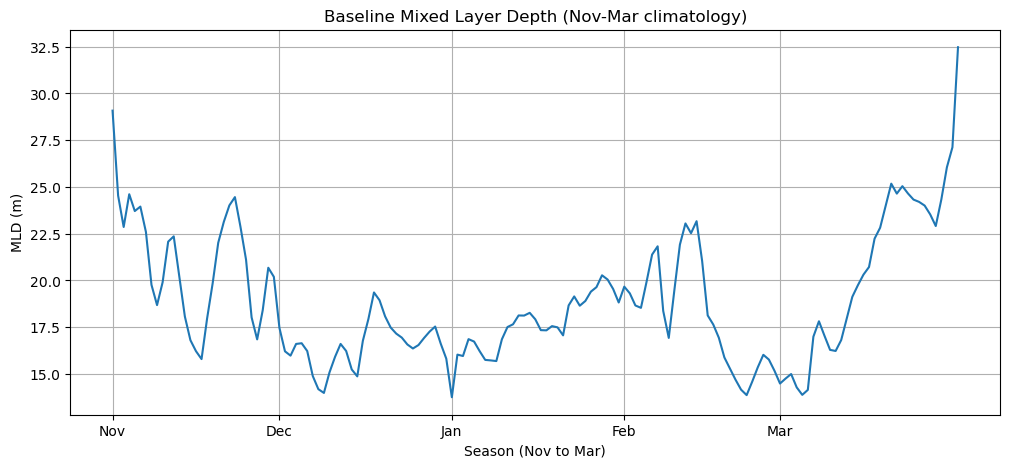

In [10]:
# Plotting baseline MLD
fig, ax = plt.subplots(figsize=(12, 5))

mld_clim.plot(ax=ax, x='season_index')

ax.set_title("Baseline Mixed Layer Depth (Nov-Mar climatology)")
ax.set_xlabel("Season (Nov to Mar)")
ax.set_ylabel("MLD (m)")
ax.grid(True)

ax.set_xticks([0, 30, 61, 92, 120])
ax.set_xticklabels(["Nov", "Dec", "Jan", "Feb", "Mar"])

In [11]:
# Convert anomaly time to "days since first data point" so I can plot it
mld_fina_anomaly_rel = mld_fina_anomaly.copy()
mld_alfred_anomaly_rel = mld_alfred_anomaly.copy()

mld_fina_anomaly_rel['time'] = (
    mld_fina_anomaly.time - mld_fina_anomaly.time[0]
) / np.timedelta64(1, 'D')

mld_alfred_anomaly_rel['time'] = (
    mld_alfred_anomaly.time - mld_alfred_anomaly.time[0]
) / np.timedelta64(1, 'D')

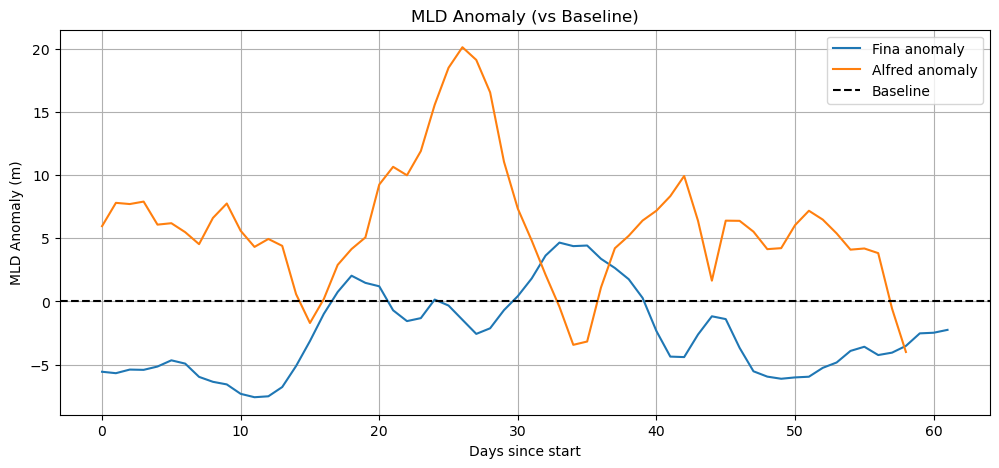

In [12]:
# Plotting anomalies versus baseline
fig, ax = plt.subplots(figsize=(12, 5))

mld_fina_anomaly_rel.plot(ax=ax, label='Fina anomaly')
mld_alfred_anomaly_rel.plot(ax=ax, label='Alfred anomaly')

ax.axhline(0, color='black', linestyle='--', label='Baseline')

ax.legend()
ax.set_title("MLD Anomaly (vs Baseline)")
ax.set_ylabel("MLD Anomaly (m)")
ax.set_xlabel("Days since start")

ax.grid(True)

## Spatial maps

In [13]:
# Spatial data for map plots
mld_alfred_3d = mld_alfred
mld_fina_3d   = mld_fina

# Combine the three baseline files spatially and take the mean
mld_baseline_spatial = xr.concat(
    [mld_baseline_first_clean, mld_baseline_second_clean, mld_baseline_third_clean],
    dim="time"
)
mld_baseline_mean_spatial = mld_baseline_spatial.mean(dim="time", skipna=True)

# Interpolating baseline to cyclone grid
baseline_on_alfred = mld_baseline_mean_spatial.interp_like(mld_alfred_3d)
baseline_on_fina   = mld_baseline_mean_spatial.interp_like(mld_fina_3d)

# Getting the anomalies spatially and not just as a timeseries
mld_alfred_anomaly = mld_alfred_3d - baseline_on_alfred
mld_fina_anomaly   = mld_fina_3d - baseline_on_fina

Text(0.5, 1.0, 'Mean deviation (anomaly) for cyclone Alfred')

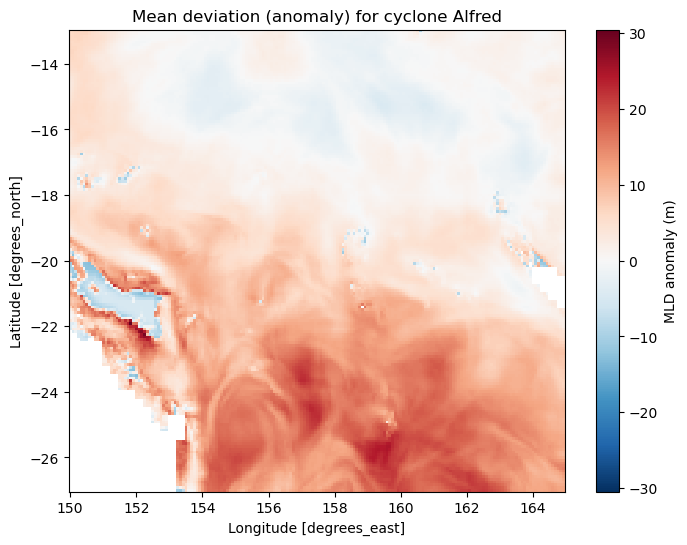

In [14]:
# Mean anomaly map for Alfred
fig, ax = plt.subplots(figsize=(8,6))

mld_alfred_anomaly.mean(dim="time", skipna=True).plot(
    ax=ax,
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "MLD anomaly (m)"}
)

ax.set_title("Mean deviation (anomaly) for cyclone Alfred")

Text(0.5, 1.0, 'Mean deviation (anomaly) for cyclone Fina')

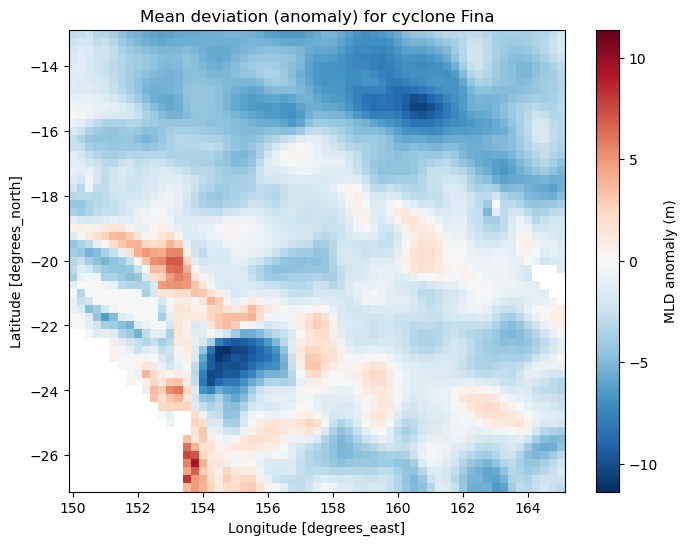

In [15]:
# Mean anomaly map for Fina
fig, ax = plt.subplots(figsize=(8,6))

mld_fina_anomaly.mean(dim="time", skipna=True).plot(
    ax=ax,
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "MLD anomaly (m)"}
)

ax.set_title("Mean deviation (anomaly) for cyclone Fina")

c:\Users\tilde\anaconda3\envs\digiocean\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Text(0.5, 1.0, 'Standard deviation map for cyclone Alfred')

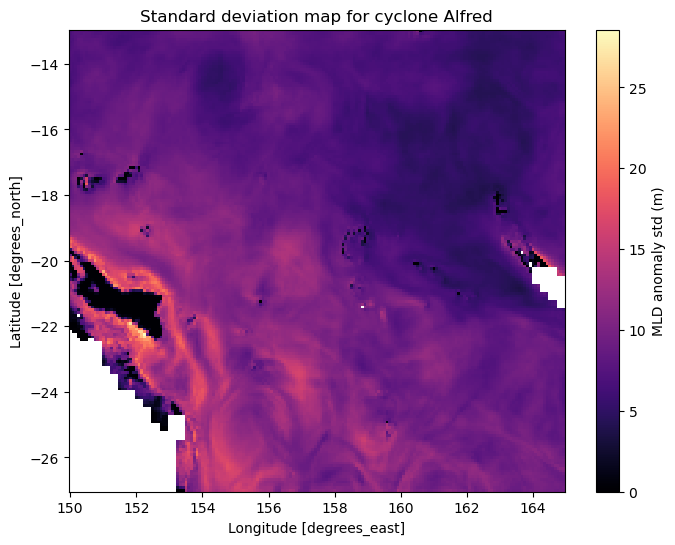

In [16]:
# Standard deviation map for Alfred
fig, ax = plt.subplots(figsize=(8,6))

mld_alfred_anomaly.std(dim="time", skipna=True).plot(
    ax=ax,
    cmap="magma",
    cbar_kwargs={"label": "MLD anomaly std (m)"}
)

ax.set_title("Standard deviation map for cyclone Alfred")

c:\Users\tilde\anaconda3\envs\digiocean\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Text(0.5, 1.0, 'Standard deviation map for cyclone Fina')

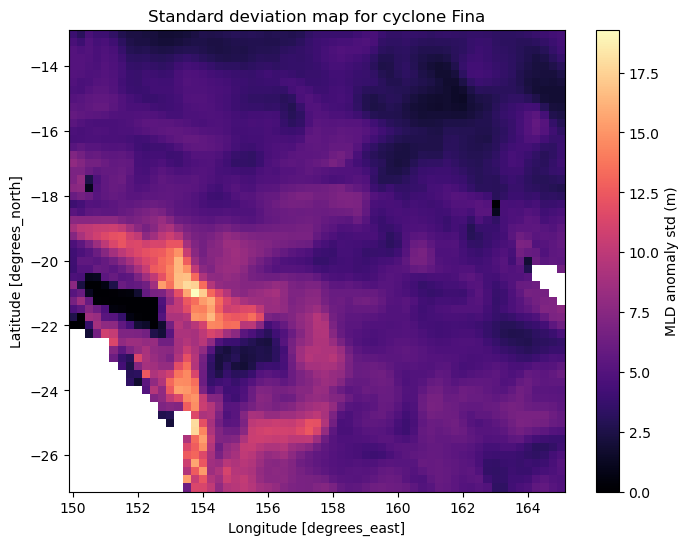

In [17]:
# Standard deviation map for Fina
fig, ax = plt.subplots(figsize=(8,6))

mld_fina_anomaly.std(dim="time", skipna=True).plot(
    ax=ax,
    cmap="magma",
    cbar_kwargs={"label": "MLD anomaly std (m)"}
)

ax.set_title("Standard deviation map for cyclone Fina")

## Statistics


In [62]:
def add_season_day(da):
    """Add a coordinate counting days since November 1 of the same season."""
    time = da.time.to_index()
    season_start = time.map(
        lambda t: pd.Timestamp(t.year if t.month >= 11 else t.year - 1, 11, 1)
    )
    season_day = (time - season_start).days
    return da.assign_coords(season_day=("time", season_day))


def cyclone_peak_vs_baseline_seasonal_day(
    cyclone_da,
    baseline_da,
    peak_date,
    time_window=0,   # how many days either side of peak_date to average over
):
    """
    Compare the cyclone peak (spatial map) against the baseline
    distribution on the same seasonal day.
    Returns anomaly, z-score, and percentile maps.
    """
    # Add seasonal-day coordinate to baseline
    baseline_da = add_season_day(baseline_da)

    # Cyclone spatial average over the peak window
    cyclone_peak = cyclone_da.sel(
        time=slice(
            np.datetime64(peak_date) - np.timedelta64(time_window, "D"),
            np.datetime64(peak_date) + np.timedelta64(time_window, "D"),
        )
    ).mean("time")

    # Find which seasonal day the peak date falls on
    # Extract the time value and compute seasonal day directly
    peak_time_value = cyclone_da.sel(time=peak_date).time.values
    peak_ts = pd.Timestamp(peak_time_value)
    season_start = pd.Timestamp(
        peak_ts.year if peak_ts.month >= 11 else peak_ts.year - 1, 11, 1
    )
    peak_sd = (peak_ts - season_start).days

    # Select only that seasonal day from the baseline
    baseline_sd = baseline_da.where(
        baseline_da.season_day == peak_sd,
        drop=True
    )

    # Compute mean and std over time
    baseline_mean = baseline_sd.mean("time")
    baseline_std  = baseline_sd.std("time")
    
    # Interpolate spatially to cyclone grid (only lat/lon, not time)
    baseline_mean_interp = baseline_mean.interp(
        latitude=cyclone_peak.latitude,
        longitude=cyclone_peak.longitude,
        method='linear'
    )
    
    # For percentile calculation, interpolate each time slice of baseline_sd
    baseline_sd_interp_list = []
    for t in baseline_sd.time:
        time_slice = baseline_sd.sel(time=t).interp(
            latitude=cyclone_peak.latitude,
            longitude=cyclone_peak.longitude,
            method='linear'
        )
        baseline_sd_interp_list.append(time_slice)
    
    baseline_sd_interp = xr.concat(baseline_sd_interp_list, dim='time')

    anomaly = cyclone_peak - baseline_mean_interp
    zscore  = anomaly / baseline_std.interp(
        latitude=cyclone_peak.latitude,
        longitude=cyclone_peak.longitude,
        method='linear'
    )

    percentile = xr.apply_ufunc(
        percentileofscore,
        baseline_sd_interp,
        cyclone_peak,
        vectorize=True,
        input_core_dims=[["time"], []],
        output_dtypes=[float],
    )

    return xr.Dataset(
        {
            "cyclone_value": cyclone_peak,
            "baseline_mean": baseline_mean_interp,
            "anomaly":       anomaly,
            "zscore":        zscore,
            "percentile":    percentile,
            "season_day":    xr.DataArray(peak_sd),
        }
    )

In [19]:
# Combined baseline for the statistics function
mld_baseline_combined = xr.concat(
    [mld_baseline_first_clean, mld_baseline_second_clean, mld_baseline_third_clean],
    dim="time"
)

In [63]:
# Statistics for Alfred
alfred_mld_peak = cyclone_peak_vs_baseline_seasonal_day(
    cyclone_da=mld_alfred,
    baseline_da=mld_baseline_combined,
    peak_date="2025-02-28",
    time_window=0,
)

# Statistics for Fina
fina_mld_peak = cyclone_peak_vs_baseline_seasonal_day(
    cyclone_da=mld_fina,
    baseline_da=mld_baseline_combined,
    peak_date="2011-12-21",
    time_window=1,
)

c:\Users\tilde\anaconda3\envs\digiocean\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\tilde\anaconda3\envs\digiocean\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


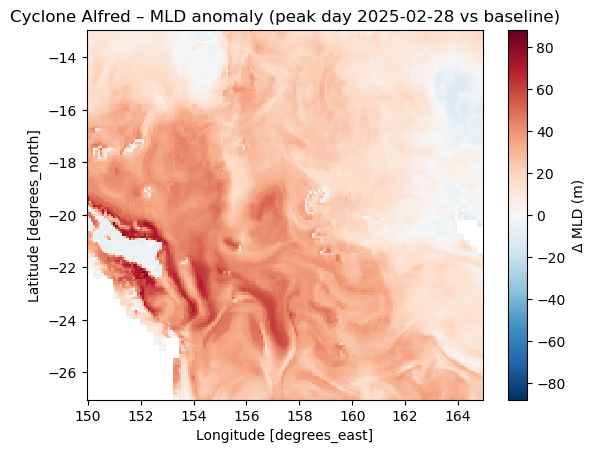

In [65]:
# Anomaly map — Alfred
alfred_mld_peak["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "\u0394 MLD (m)"},
)
plt.title("Cyclone Alfred – MLD anomaly (peak day 2025-02-28 vs baseline)")
plt.show()

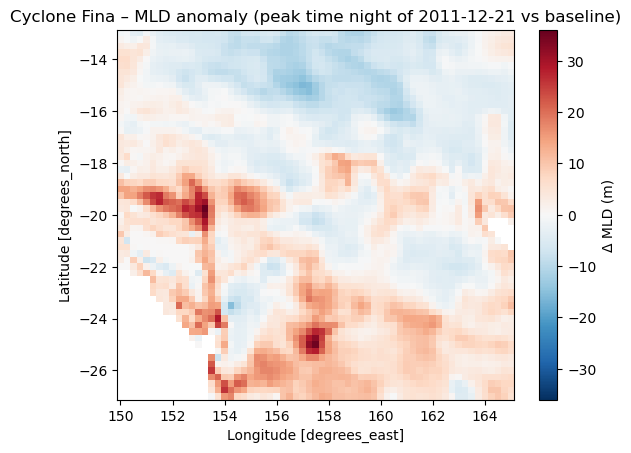

In [66]:
# Anomaly map — Fina
fina_mld_peak["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "\u0394 MLD (m)"},
)
plt.title("Cyclone Fina – MLD anomaly (peak time night of 2011-12-21 vs baseline)")
plt.show()

## One-sample t-test
We compute a 3-day mean centred on each cyclone's peak and test whether it is statistically different from the baseline 3-day mean for the same point in the season. Grid points where the difference is significant (p < 0.05) are shown in the masked plots.

In [58]:
def three_day_mean(da, center_date):
    """Compute a 3-day mean centred on center_date."""
    return da.sel(
        time=slice(
            np.datetime64(center_date) - np.timedelta64(1, "D"),
            np.datetime64(center_date) + np.timedelta64(1, "D"),
        )
    ).mean("time")


def cyclone_peak_3day_onesample_ttest(
    cyclone_da,
    baseline_das,   # list of baseline DataArrays, one per year
    peak_date,
    alpha=0.05,
    seasonal_window=7,  # Number of days before/after to include in seasonal match
):
    """
    One-sample t-test: is the cyclone 3-day mean significantly different
    from the distribution of baseline 3-day means (one value per year)?

    Returns anomaly, t-statistic, p-value, and a boolean significant map.
    """
    # Cyclone 3-day mean
    cyclone_peak = three_day_mean(cyclone_da, peak_date)

    # Compute seasonal day for the peak date (once, outside the loop)
    peak_time_value = cyclone_da.sel(time=peak_date).time.values
    peak_ts = pd.Timestamp(peak_time_value)
    season_start = pd.Timestamp(
        peak_ts.year if peak_ts.month >= 11 else peak_ts.year - 1, 11, 1
    )
    peak_sd = (peak_ts - season_start).days

    # One baseline 3-day mean per year
    baseline_means = []
    for bda in baseline_das:
        bda = add_season_day(bda)

        # Select the same seasonal day ±window in this baseline year
        baseline_window = bda.where(
            np.abs(bda.season_day - peak_sd) <= seasonal_window,
            drop=True
        )
        
        # If we have data, take the mean over time
        if baseline_window.sizes.get('time', 0) > 0:
            baseline_mean = baseline_window.mean("time")
            
            # Interpolate spatially to cyclone grid (only lat/lon, not time)
            baseline_mean_interp = baseline_mean.interp(
                latitude=cyclone_peak.latitude,
                longitude=cyclone_peak.longitude,
                method='linear'
            )
            baseline_means.append(baseline_mean_interp)
        else:
            # Create a NaN-filled array matching the cyclone_peak grid
            baseline_means.append(xr.full_like(cyclone_peak, np.nan))

    # Stack the per-year means into a "sample" dimension
    baseline_stack = xr.concat(baseline_means, dim="sample")

    # Run the t-test at every grid point
    tstat, pval = xr.apply_ufunc(
        ttest_1samp,
        baseline_stack,
        cyclone_peak,
        input_core_dims=[["sample"], []],
        output_core_dims=[[], []],
        kwargs={"nan_policy": "omit"},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float],
    )

    anomaly = cyclone_peak - baseline_stack.mean("sample")

    return xr.Dataset(
        {
            "anomaly":     anomaly,
            "t_stat":      tstat,
            "p_value":     pval,
            "significant": pval < alpha,
        }
    )

In [59]:
# Pass the three baseline files directly as the sample list for the t-test
baseline_by_year = [
    mld_baseline_first_clean,
    mld_baseline_second_clean,
    mld_baseline_third_clean,
]

In [60]:
# Run t-test for Alfred
alfred_mld_ttest = cyclone_peak_3day_onesample_ttest(
    cyclone_da=mld_alfred,
    baseline_das=baseline_by_year,
    peak_date="2025-02-28",
)

# Run t-test for Fina
fina_mld_ttest = cyclone_peak_3day_onesample_ttest(
    cyclone_da=mld_fina,
    baseline_das=baseline_by_year,
    peak_date="2011-12-21",
)

c:\Users\tilde\anaconda3\envs\digiocean\Lib\site-packages\numpy\lib\_function_base_impl.py:2630: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  results = func(*(arg[index] for arg in args))
c:\Users\tilde\anaconda3\envs\digiocean\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\tilde\anaconda3\envs\digiocean\Lib\site-packages\numpy\lib\_function_base_impl.py:2630: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  results = func(*(arg[index] for arg in args))
c:\Users\tilde\anaconda3\envs\digiocean\Lib\site-packages\scipy\stats\_

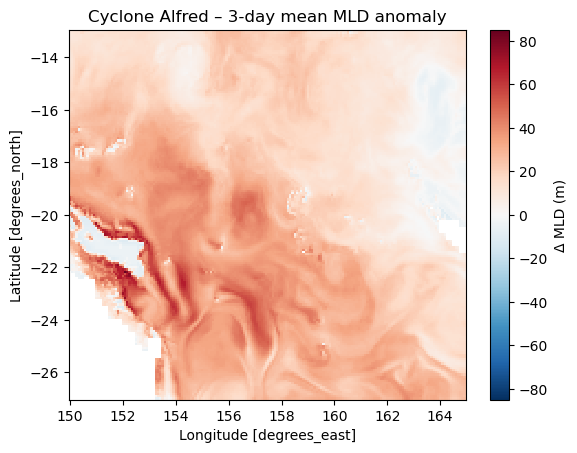

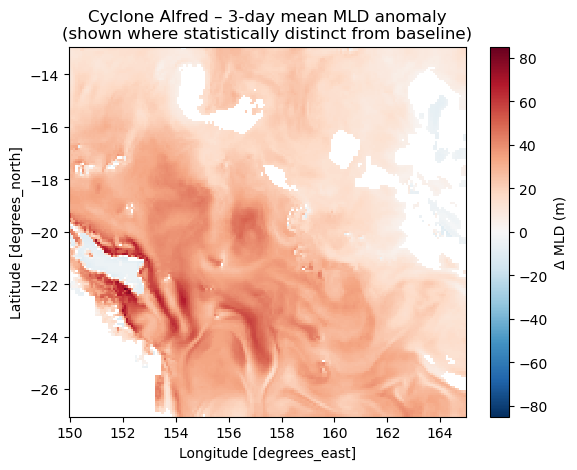

In [55]:
# Full anomaly map — Alfred
alfred_mld_ttest["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "\u0394 MLD (m)"},
)
plt.title("Cyclone Alfred – 3-day mean MLD anomaly")
plt.show()

# Masked to significant grid points only — Alfred
alfred_mld_ttest["anomaly"].where(alfred_mld_ttest["significant"]).plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "\u0394 MLD (m)"},
)
plt.title(
    "Cyclone Alfred – 3-day mean MLD anomaly\n"
    "(shown where statistically distinct from baseline)"
)
plt.show()

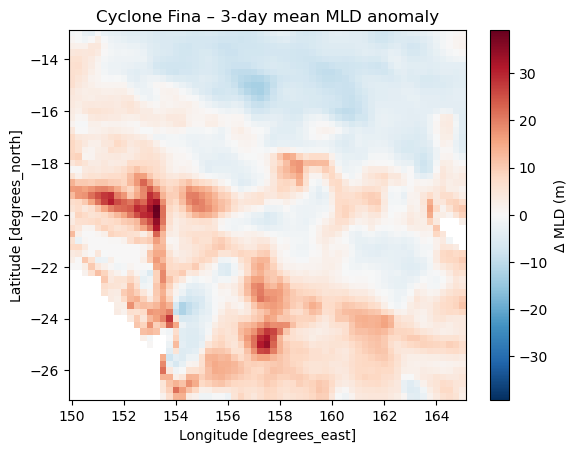

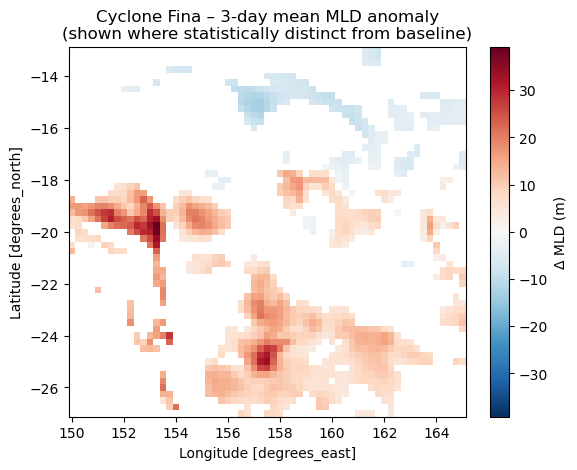

In [56]:
# Full anomaly map — Fina
fina_mld_ttest["anomaly"].plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "\u0394 MLD (m)"},
)
plt.title("Cyclone Fina – 3-day mean MLD anomaly")
plt.show()

# Masked to significant grid points only — Fina
fina_mld_ttest["anomaly"].where(fina_mld_ttest["significant"]).plot(
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "\u0394 MLD (m)"},
)
plt.title(
    "Cyclone Fina – 3-day mean MLD anomaly\n"
    "(shown where statistically distinct from baseline)"
)
plt.show()